In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [35]:
data=pd.read_csv('weather_pollution_1000.csv')

In [36]:
data.head()

,datetime,temperature,humidity,wind_speed,pressure,pm2_5
0,2024-01-01 00:00:00,30.894076,42.769890,1.441786,1008.417281,66.337316
1,2024-01-01 01:00:00,18.584180,53.538244,6.192956,993.814389,61.987653
2,2024-01-01 02:00:00,16.805544,81.092883,3.822236,1026.409389,10.321667
3,2024-01-01 03:00:00,26.539443,37.656733,7.859906,1016.720739,133.182841
4,2024-01-01 04:00:00,31.584069,83.631922,6.249263,1010.398838,103.089616


In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     1000 non-null   object 
 1   temperature  1000 non-null   float64
 2   humidity     1000 non-null   float64
 3   wind_speed   1000 non-null   float64
 4   pressure     1000 non-null   float64
 5   pm2_5        1000 non-null   float64
dtypes: float64(5), object(1)
memory usage: 47.0+ KB


In [38]:
data.describe()

,temperature,humidity,wind_speed,pressure,pm2_5
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.834590,60.272081,6.169864,1010.331248,74.876797
std,8.595250,17.059168,3.536326,11.696902,42.089286
min,9.358842,28.358659,0.235054,989.512151,3.732783
25%,17.724807,45.978532,2.926395,999.642917,39.257913
50%,24.391498,59.642885,6.183385,1011.382077,75.631039
75%,31.789867,74.857376,9.351831,1020.377264,109.918747
max,40.673974,91.171985,12.171295,1030.520248,154.298469


In [39]:
data.isnull().sum()

datetime       0
temperature    0
humidity       0
wind_speed     0
pressure       0
pm2_5          0
dtype: int64

In [40]:
data_info= pd.to_datetime(data['datetime'])
print(data_info)

0     2024-01-01 00:00:00
1     2024-01-01 01:00:00
2     2024-01-01 02:00:00
3     2024-01-01 03:00:00
4     2024-01-01 04:00:00
              ...        
995   2024-01-21 15:00:00
996   2024-01-21 16:00:00
997   2024-01-21 17:00:00
998   2024-01-21 18:00:00
999   2024-01-21 19:00:00
Name: datetime, Length: 1000, dtype: datetime64[ns]


In [41]:
data['datetime']=pd.to_datetime(data['datetime'])
data['year']=data['datetime'].dt.year
data['month']=data['datetime'].dt.month
data['day']=data['datetime'].dt.day
data['day_of_week'] = pd.to_datetime(data['datetime']).dt.dayofweek
data['hour'] = pd.to_datetime(data['datetime']).dt.hour
data

,datetime,temperature,humidity,wind_speed,pressure,pm2_5,year,month,day,day_of_week,hour
0,2024-01-01 00:00:00,30.894076,42.769890,1.441786,1008.417281,66.337316,2024,1,1,0,0
1,2024-01-01 01:00:00,18.584180,53.538244,6.192956,993.814389,61.987653,2024,1,1,0,1
2,2024-01-01 02:00:00,16.805544,81.092883,3.822236,1026.409389,10.321667,2024,1,1,0,2
3,2024-01-01 03:00:00,26.539443,37.656733,7.859906,1016.720739,133.182841,2024,1,1,0,3
4,2024-01-01 04:00:00,31.584069,83.631922,6.249263,1010.398838,103.089616,2024,1,1,0,4
...,...,...,...,...,...,...,...,...,...,...,...
995,2024-01-21 15:00:00,39.649352,45.624306,8.218732,998.346516,147.278056,2024,1,21,6,15
996,2024-01-21 16:00:00,36.035950,72.986836,3.074559,1019.250501,120.572736,2024,1,21,6,16
997,2024-01-21 17:00:00,37.502434,51.374863,2.242112,1000.472572,91.106400,2024,1,21,6,17
998,2024-01-21 18:00:00,22.089077,29.763375,11.469020,1018.777309,14.865232,2024,1,21,6,18


In [42]:
data["target"] = (data["pm2_5"] > 135).astype(int)
data

,datetime,temperature,humidity,wind_speed,pressure,pm2_5,year,month,day,day_of_week,hour,target
0,2024-01-01 00:00:00,30.894076,42.769890,1.441786,1008.417281,66.337316,2024,1,1,0,0,0
1,2024-01-01 01:00:00,18.584180,53.538244,6.192956,993.814389,61.987653,2024,1,1,0,1,0
2,2024-01-01 02:00:00,16.805544,81.092883,3.822236,1026.409389,10.321667,2024,1,1,0,2,0
3,2024-01-01 03:00:00,26.539443,37.656733,7.859906,1016.720739,133.182841,2024,1,1,0,3,0
4,2024-01-01 04:00:00,31.584069,83.631922,6.249263,1010.398838,103.089616,2024,1,1,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,2024-01-21 15:00:00,39.649352,45.624306,8.218732,998.346516,147.278056,2024,1,21,6,15,1
996,2024-01-21 16:00:00,36.035950,72.986836,3.074559,1019.250501,120.572736,2024,1,21,6,16,0
997,2024-01-21 17:00:00,37.502434,51.374863,2.242112,1000.472572,91.106400,2024,1,21,6,17,0
998,2024-01-21 18:00:00,22.089077,29.763375,11.469020,1018.777309,14.865232,2024,1,21,6,18,0


In [43]:
X = data.iloc[:, :-1].values    # كل الأعمدة ما عدا target
y = data.iloc[:, -1].values # target 
data

,datetime,temperature,humidity,wind_speed,pressure,pm2_5,year,month,day,day_of_week,hour,target
0,2024-01-01 00:00:00,30.894076,42.769890,1.441786,1008.417281,66.337316,2024,1,1,0,0,0
1,2024-01-01 01:00:00,18.584180,53.538244,6.192956,993.814389,61.987653,2024,1,1,0,1,0
2,2024-01-01 02:00:00,16.805544,81.092883,3.822236,1026.409389,10.321667,2024,1,1,0,2,0
3,2024-01-01 03:00:00,26.539443,37.656733,7.859906,1016.720739,133.182841,2024,1,1,0,3,0
4,2024-01-01 04:00:00,31.584069,83.631922,6.249263,1010.398838,103.089616,2024,1,1,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,2024-01-21 15:00:00,39.649352,45.624306,8.218732,998.346516,147.278056,2024,1,21,6,15,1
996,2024-01-21 16:00:00,36.035950,72.986836,3.074559,1019.250501,120.572736,2024,1,21,6,16,0
997,2024-01-21 17:00:00,37.502434,51.374863,2.242112,1000.472572,91.106400,2024,1,21,6,17,0
998,2024-01-21 18:00:00,22.089077,29.763375,11.469020,1018.777309,14.865232,2024,1,21,6,18,0


In [44]:
data.drop('datetime',axis=1,inplace=True)
data

,temperature,humidity,wind_speed,pressure,pm2_5,year,month,day,day_of_week,hour,target
0,30.894076,42.769890,1.441786,1008.417281,66.337316,2024,1,1,0,0,0
1,18.584180,53.538244,6.192956,993.814389,61.987653,2024,1,1,0,1,0
2,16.805544,81.092883,3.822236,1026.409389,10.321667,2024,1,1,0,2,0
3,26.539443,37.656733,7.859906,1016.720739,133.182841,2024,1,1,0,3,0
4,31.584069,83.631922,6.249263,1010.398838,103.089616,2024,1,1,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...
995,39.649352,45.624306,8.218732,998.346516,147.278056,2024,1,21,6,15,1
996,36.035950,72.986836,3.074559,1019.250501,120.572736,2024,1,21,6,16,0
997,37.502434,51.374863,2.242112,1000.472572,91.106400,2024,1,21,6,17,0
998,22.089077,29.763375,11.469020,1018.777309,14.865232,2024,1,21,6,18,0


In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  1000 non-null   float64
 1   humidity     1000 non-null   float64
 2   wind_speed   1000 non-null   float64
 3   pressure     1000 non-null   float64
 4   pm2_5        1000 non-null   float64
 5   year         1000 non-null   int64  
 6   month        1000 non-null   int64  
 7   day          1000 non-null   int64  
 8   day_of_week  1000 non-null   int64  
 9   hour         1000 non-null   int64  
 10  target       1000 non-null   int32  
dtypes: float64(5), int32(1), int64(5)
memory usage: 82.2 KB


In [46]:
data.corr()

,temperature,humidity,wind_speed,pressure,pm2_5,year,month,day,day_of_week,hour,target
temperature,1.000000,0.051668,-0.066394,-0.010207,0.055038,NaN,NaN,-0.022777,0.016378,0.074178,0.029777
humidity,0.051668,1.000000,0.020630,-0.029092,-0.070509,NaN,NaN,-0.091492,-0.051492,0.010300,0.043608
wind_speed,-0.066394,0.020630,1.000000,-0.009800,-0.065365,NaN,NaN,0.083802,0.008796,0.068649,0.011068
pressure,-0.010207,-0.029092,-0.009800,1.000000,-0.059173,NaN,NaN,0.004727,-0.011656,0.002264,-0.042969
pm2_5,0.055038,-0.070509,-0.065365,-0.059173,1.000000,NaN,NaN,-0.003848,0.025639,-0.002169,0.478276
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,-0.022777,-0.091492,0.083802,0.004727,-0.003848,NaN,NaN,1.000000,0.316779,-0.019463,0.009441
day_of_week,0.016378,-0.051492,0.008796,-0.011656,0.025639,NaN,NaN,0.316779,1.000000,-0.017643,0.033196
hour,0.074178,0.010300,0.068649,0.002264,-0.002169,NaN,NaN,-0.019463,-0.017643,1.000000,-0.007810


In [47]:
data.drop(['year','month'],axis=1,inplace=True)
data

,temperature,humidity,wind_speed,pressure,pm2_5,day,day_of_week,hour,target
0,30.894076,42.769890,1.441786,1008.417281,66.337316,1,0,0,0
1,18.584180,53.538244,6.192956,993.814389,61.987653,1,0,1,0
2,16.805544,81.092883,3.822236,1026.409389,10.321667,1,0,2,0
3,26.539443,37.656733,7.859906,1016.720739,133.182841,1,0,3,0
4,31.584069,83.631922,6.249263,1010.398838,103.089616,1,0,4,0
...,...,...,...,...,...,...,...,...,...
995,39.649352,45.624306,8.218732,998.346516,147.278056,21,6,15,1
996,36.035950,72.986836,3.074559,1019.250501,120.572736,21,6,16,0
997,37.502434,51.374863,2.242112,1000.472572,91.106400,21,6,17,0
998,22.089077,29.763375,11.469020,1018.777309,14.865232,21,6,18,0


In [48]:
data['temp_day'] = data['temperature'] * data['day_of_week']
data['temp_wind'] = data['temperature'] * data['wind_speed']
data['wind_day'] = data['wind_speed'] * data['day_of_week']
data['wind_hour'] = data['wind_speed'] * data['hour']
data['hum_hour'] = data['humidity'] * data['hour']
data['hour_day'] = data['hour'] * data['day_of_week']
data['hum_wind'] = data['humidity'] * data['wind_speed']
data['temp_hum'] = data['temperature'] * data['humidity']
data

,temperature,humidity,wind_speed,pressure,pm2_5,day,day_of_week,hour,target,temp_day,temp_wind,wind_day,wind_hour,hum_hour,hour_day,hum_wind,temp_hum
0,30.894076,42.769890,1.441786,1008.417281,66.337316,1,0,0,0,0.000000,44.542647,0.000000,0.000000,0.000000,0,61.665031,1321.336211
1,18.584180,53.538244,6.192956,993.814389,61.987653,1,0,1,0,0.000000,115.091005,0.000000,6.192956,53.538244,0,331.559978,994.964371
2,16.805544,81.092883,3.822236,1026.409389,10.321667,1,0,2,0,0.000000,64.234750,0.000000,7.644472,162.185766,0,309.956120,1362.809983
3,26.539443,37.656733,7.859906,1016.720739,133.182841,1,0,3,0,0.000000,208.597541,0.000000,23.579719,112.970200,0,295.978404,999.388734
4,31.584069,83.631922,6.249263,1010.398838,103.089616,1,0,4,0,0.000000,197.377167,0.000000,24.997054,334.527688,0,522.637909,2641.436405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,39.649352,45.624306,8.218732,998.346516,147.278056,21,6,15,1,237.896112,325.867413,49.312394,123.280986,684.364590,90,374.973961,1808.974168
996,36.035950,72.986836,3.074559,1019.250501,120.572736,21,6,16,0,216.215702,110.794637,18.447351,49.192936,1167.789372,96,224.402296,2630.149984
997,37.502434,51.374863,2.242112,1000.472572,91.106400,21,6,17,0,225.014605,84.084664,13.452673,38.115907,873.372667,102,115.188206,1926.682408
998,22.089077,29.763375,11.469020,1018.777309,14.865232,21,6,18,0,132.534465,253.340066,68.814119,206.442356,535.740745,108,341.356733,657.445489


In [49]:
data.drop(['hour','day'],axis=1,inplace=True)
data

,temperature,humidity,wind_speed,pressure,pm2_5,day_of_week,target,temp_day,temp_wind,wind_day,wind_hour,hum_hour,hour_day,hum_wind,temp_hum
0,30.894076,42.769890,1.441786,1008.417281,66.337316,0,0,0.000000,44.542647,0.000000,0.000000,0.000000,0,61.665031,1321.336211
1,18.584180,53.538244,6.192956,993.814389,61.987653,0,0,0.000000,115.091005,0.000000,6.192956,53.538244,0,331.559978,994.964371
2,16.805544,81.092883,3.822236,1026.409389,10.321667,0,0,0.000000,64.234750,0.000000,7.644472,162.185766,0,309.956120,1362.809983
3,26.539443,37.656733,7.859906,1016.720739,133.182841,0,0,0.000000,208.597541,0.000000,23.579719,112.970200,0,295.978404,999.388734
4,31.584069,83.631922,6.249263,1010.398838,103.089616,0,0,0.000000,197.377167,0.000000,24.997054,334.527688,0,522.637909,2641.436405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,39.649352,45.624306,8.218732,998.346516,147.278056,6,1,237.896112,325.867413,49.312394,123.280986,684.364590,90,374.973961,1808.974168
996,36.035950,72.986836,3.074559,1019.250501,120.572736,6,0,216.215702,110.794637,18.447351,49.192936,1167.789372,96,224.402296,2630.149984
997,37.502434,51.374863,2.242112,1000.472572,91.106400,6,0,225.014605,84.084664,13.452673,38.115907,873.372667,102,115.188206,1926.682408
998,22.089077,29.763375,11.469020,1018.777309,14.865232,6,0,132.534465,253.340066,68.814119,206.442356,535.740745,108,341.356733,657.445489


In [50]:
data.corr()

,temperature,humidity,wind_speed,pressure,pm2_5,day_of_week,target,temp_day,temp_wind,wind_day,wind_hour,hum_hour,hour_day,hum_wind,temp_hum
temperature,1.000000,0.051668,-0.066394,-0.010207,0.055038,0.016378,0.029777,0.466200,0.458231,-0.049135,-0.005432,0.090606,0.060718,-0.025491,0.772951
humidity,0.051668,1.000000,0.020630,-0.029092,-0.070509,-0.051492,0.043608,0.005055,0.054840,-0.028101,-0.005847,0.414960,-0.000670,0.462019,0.637362
wind_speed,-0.066394,0.020630,1.000000,-0.009800,-0.065365,0.008796,0.011068,-0.035537,0.808726,0.602487,0.660919,0.051457,0.032725,0.863816,-0.028423
pressure,-0.010207,-0.029092,-0.009800,1.000000,-0.059173,-0.011656,-0.042969,-0.021326,-0.001409,-0.007371,-0.022373,-0.012501,0.010596,-0.007474,-0.015322
pm2_5,0.055038,-0.070509,-0.065365,-0.059173,1.000000,0.025639,0.478276,0.052961,-0.032926,-0.010714,-0.042877,-0.009771,-0.006261,-0.087417,-0.002649
day_of_week,0.016378,-0.051492,0.008796,-0.011656,0.025639,1.000000,0.033196,0.846155,0.000975,0.693205,-0.020715,-0.019523,0.671395,-0.016868,-0.000351
target,0.029777,0.043608,0.011068,-0.042969,0.478276,0.033196,1.000000,0.039650,0.031257,0.027926,-0.006823,0.019718,-0.015362,0.037995,0.048314
temp_day,0.466200,0.005055,-0.035537,-0.021326,0.052961,0.846155,0.039650,1.000000,0.196330,0.543431,-0.030756,0.039298,0.594637,-0.022057,0.364248
temp_wind,0.458231,0.054840,0.808726,-0.001409,-0.032926,0.000975,0.031257,0.196330,1.000000,0.477112,0.548565,0.082496,0.037587,0.722835,0.380260
wind_day,-0.049135,-0.028101,0.602487,-0.007371,-0.010714,0.693205,0.027926,0.543431,0.477112,1.000000,0.367533,0.011676,0.485453,0.500602,-0.029948


<AxesSubplot:xlabel='humidity', ylabel='pm2_5'>

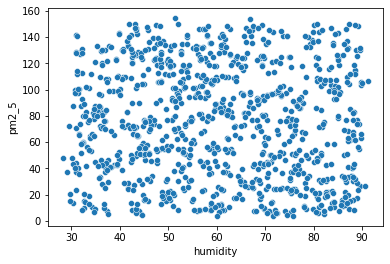

In [51]:
sns.scatterplot(x="humidity",y="pm2_5",data=data)

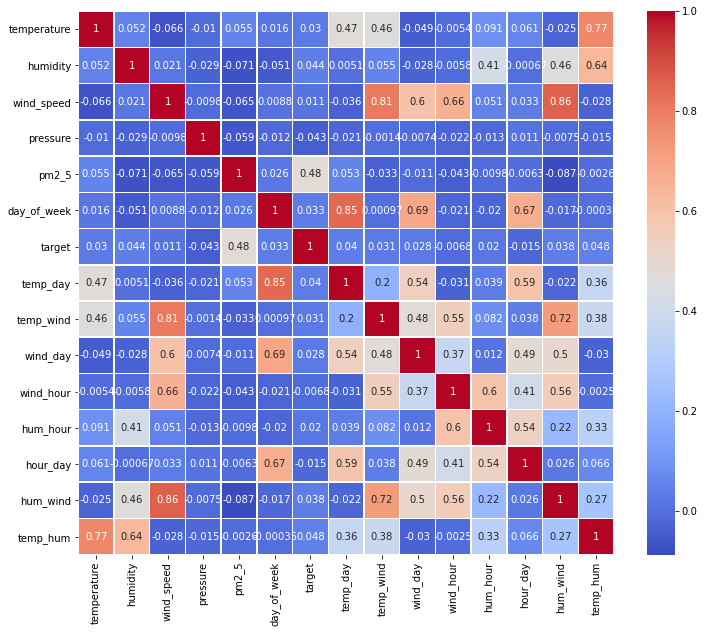

<Figure size 3600x3600 with 0 Axes>

In [52]:
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(),annot=True,cmap="coolwarm", linewidth=0.5)
plt.show()

In [53]:
features = ["temperature","humidity","wind_speed","pressure",'day_of_week',"hour_day","temp_hum","hum_wind","temp_wind"]

X = data[features]  
y = data["target"]   
data

,temperature,humidity,wind_speed,pressure,pm2_5,day_of_week,target,temp_day,temp_wind,wind_day,wind_hour,hum_hour,hour_day,hum_wind,temp_hum
0,30.894076,42.769890,1.441786,1008.417281,66.337316,0,0,0.000000,44.542647,0.000000,0.000000,0.000000,0,61.665031,1321.336211
1,18.584180,53.538244,6.192956,993.814389,61.987653,0,0,0.000000,115.091005,0.000000,6.192956,53.538244,0,331.559978,994.964371
2,16.805544,81.092883,3.822236,1026.409389,10.321667,0,0,0.000000,64.234750,0.000000,7.644472,162.185766,0,309.956120,1362.809983
3,26.539443,37.656733,7.859906,1016.720739,133.182841,0,0,0.000000,208.597541,0.000000,23.579719,112.970200,0,295.978404,999.388734
4,31.584069,83.631922,6.249263,1010.398838,103.089616,0,0,0.000000,197.377167,0.000000,24.997054,334.527688,0,522.637909,2641.436405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,39.649352,45.624306,8.218732,998.346516,147.278056,6,1,237.896112,325.867413,49.312394,123.280986,684.364590,90,374.973961,1808.974168
996,36.035950,72.986836,3.074559,1019.250501,120.572736,6,0,216.215702,110.794637,18.447351,49.192936,1167.789372,96,224.402296,2630.149984
997,37.502434,51.374863,2.242112,1000.472572,91.106400,6,0,225.014605,84.084664,13.452673,38.115907,873.372667,102,115.188206,1926.682408
998,22.089077,29.763375,11.469020,1018.777309,14.865232,6,0,132.534465,253.340066,68.814119,206.442356,535.740745,108,341.356733,657.445489


In [54]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.22, random_state=40)

In [55]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [56]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

Accuracy: 0.9272727272727272

Confusion Matrix:
 [[204   0]
 [ 16   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96       204
           1       0.00      0.00      0.00        16

    accuracy                           0.93       220
   macro avg       0.46      0.50      0.48       220
weighted avg       0.86      0.93      0.89       220



C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [57]:
print("Model Score:", model.score(X_test, y_test))

Model Score: 0.9272727272727272


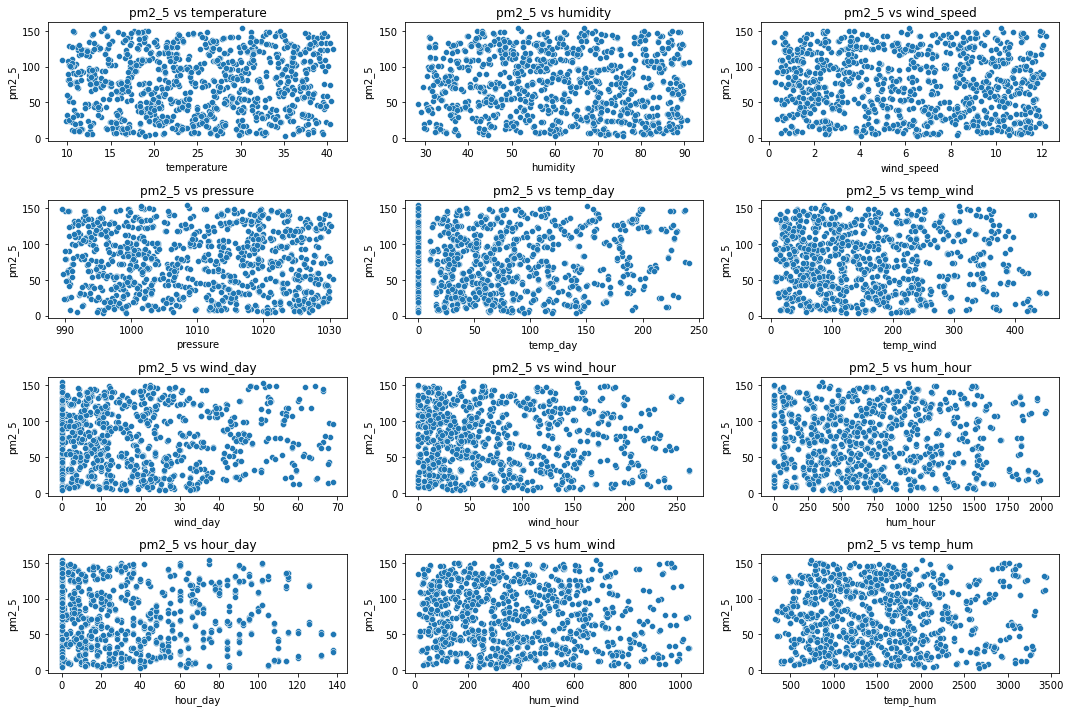


Sample Prediction Class: 0
Prediction Probabilities: [0.92448851 0.07551149]
الجو آمن.. التلوث منخفض وغير مؤثر على مرضى الصدر.


In [58]:
plt.figure(figsize=(15, 10))
plot_features = [
    'temperature', 'humidity', 'wind_speed', 'pressure',
    'temp_day', 'temp_wind', 'wind_day', 'wind_hour',
    'hum_hour', 'hour_day', 'hum_wind', 'temp_hum'
]
for i, feature in enumerate(plot_features):
    plt.subplot(4, 3, i+1)
    sns.scatterplot(x=data[feature], y=data['pm2_5'])
    plt.title(f'pm2_5 vs {feature}')

plt.tight_layout()
plt.show()
sample_pred_class = model.predict([X_test[0]])[0]  
sample_pred_prob = model.predict_proba([X_test[0]])[0]  

print("\nSample Prediction Class:", sample_pred_class)
print("Prediction Probabilities:", sample_pred_prob)
if sample_pred_class == 'High':
    print("تحذير: التلوث عالي جدًا.. مرضى الصدر لا يفضل خروجهم اليوم.")
else:
    print("الجو آمن.. التلوث منخفض وغير مؤثر على مرضى الصدر.")